### Import Necessary Libs

In [453]:
import os
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt

root_pth = '/nas/datasets/Tensor-Time-Series-Dataset/Processed_Data'
output_csv_pth = '/home/wangzihan/workspace/TTS_results/csv'
output_img_pth = '/home/wangzihan/workspace/TTS_results/imgs'

### Implement Plot Methods

In [454]:
class PlotSeries:
    def __init__(self, dataset_name) -> None:
        # get data from pkl file 
        self.dataset_name = dataset_name
        pkl_name = dataset_name + '.pkl'
        pkl_path = os.path.join(root_pth, dataset_name, pkl_name)
        if not os.path.exists(pkl_path):
            raise FileExistsError(f"Can not find file: {pkl_path}")
        with open(pkl_path, 'rb') as file:
            self.data_pkl = pkl.load(file)
            self.data = self.data_pkl['data']
        # transform data to 2D MTS array
        self.transform_and_measure() # get timesteps and channel property
    
    def transform_and_measure(self):
        temp = self.data.reshape(self.data.shape[0], -1, 1)
        self.data = np.squeeze(temp, axis=-1)
        self.data_shape =self.data.shape
        self.timesteps = self.data_shape[0]
        self.channel_nums = self.data_shape[1]
    
    def plot(self, win=0, plot_num=5, normalize=False):
        plt.figure(figsize=(12, 6))
        x = np.arange(self.timesteps)
        import random, datetime
        random.seed(datetime.datetime.now().timestamp())
        start = random.randint(0, self.timesteps-win)
        for i in range(plot_num):
            if win == 0:
                plt.plot(x, self.data[:, i], label=f'channel {i+1}')
            else:
                row = random.randint(0, self.channel_nums-1) # pick (plot_num) random channels
                # normalize to see trend and seasonality
                if normalize:
                    series = (self.data[start:start+win, row] - np.mean(self.data[start:start+win, row]))/(np.std(self.data[start:start+win, row])+0.5)
                else:
                    series = self.data[start:start+win, row]
                plt.plot(x[:win], series, label=f'channel {row+1}')
            plt.xlabel('Time')
            plt.ylabel('Value')
        plt.title(f'{self.dataset_name.upper()}, window length={win}')
        plt.show()

### Plot and Show

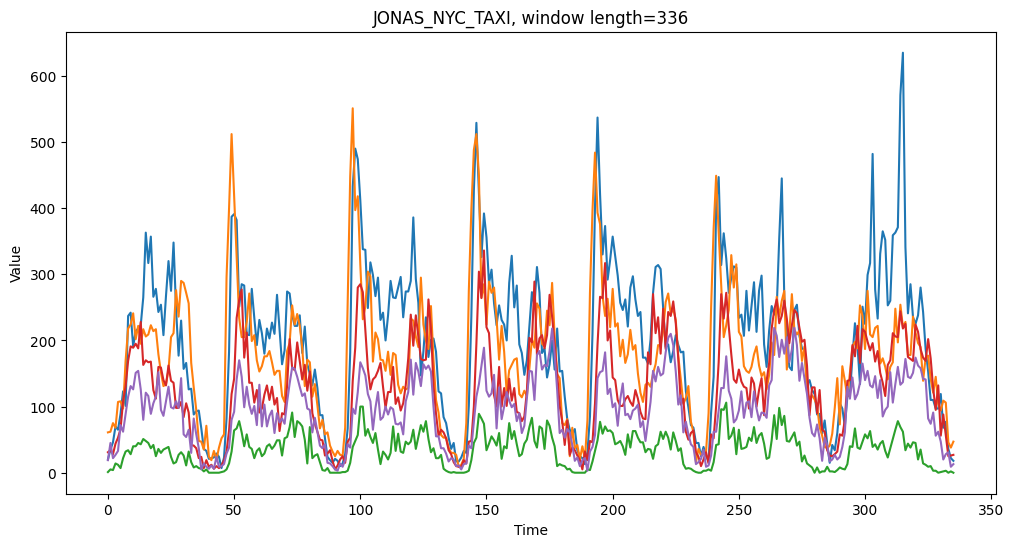

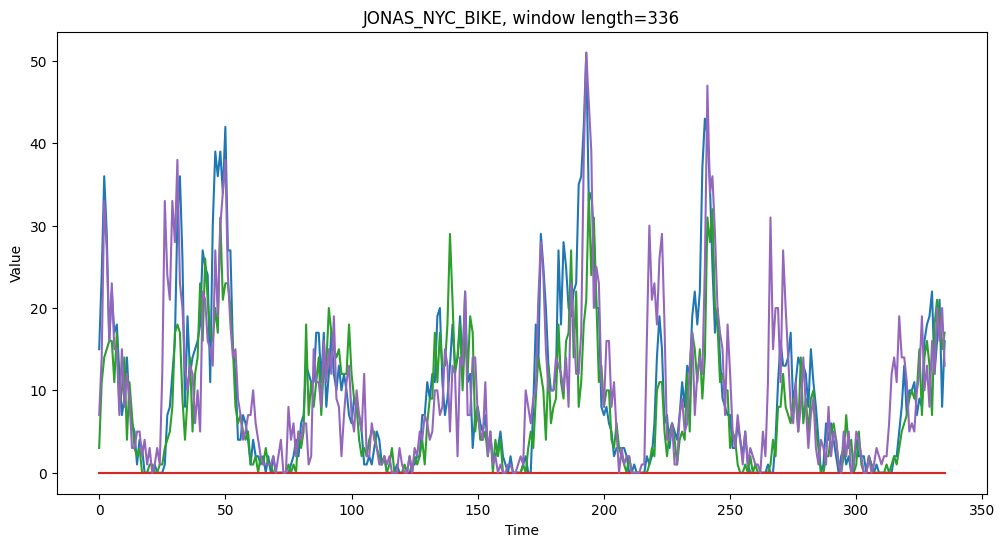

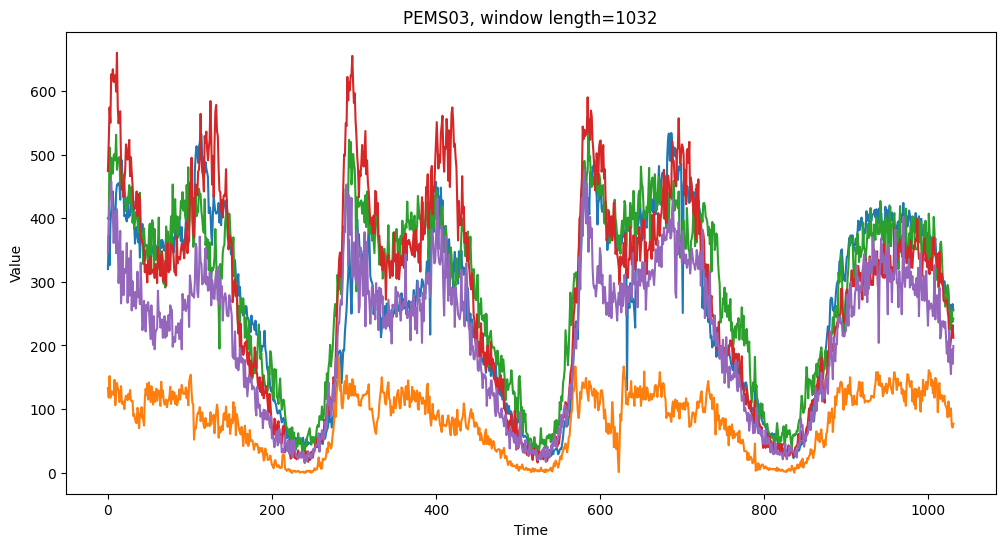

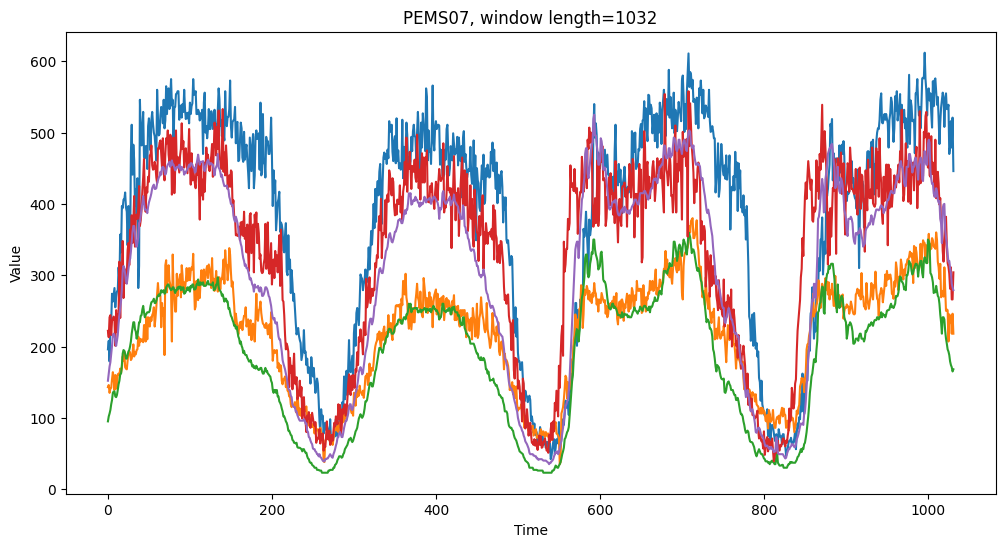

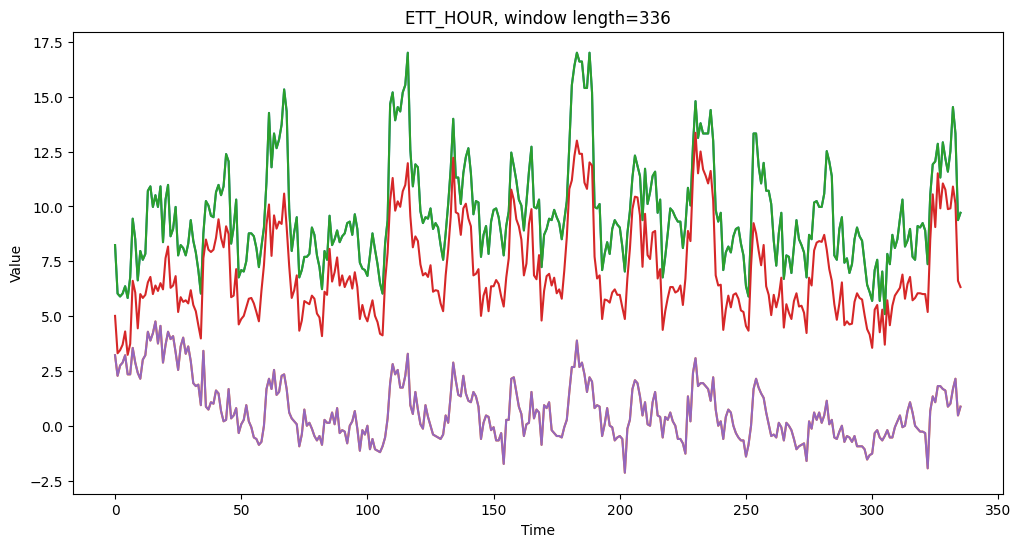

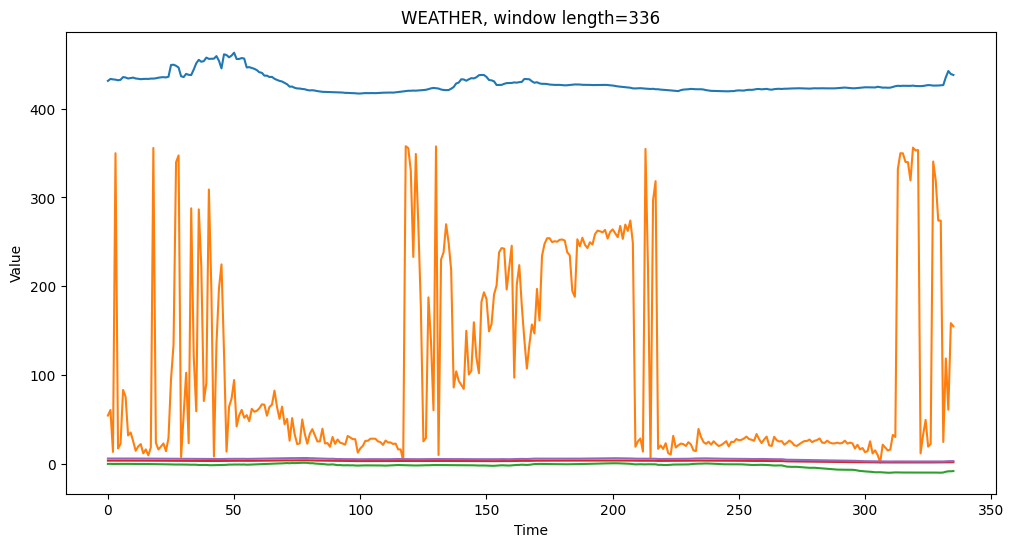

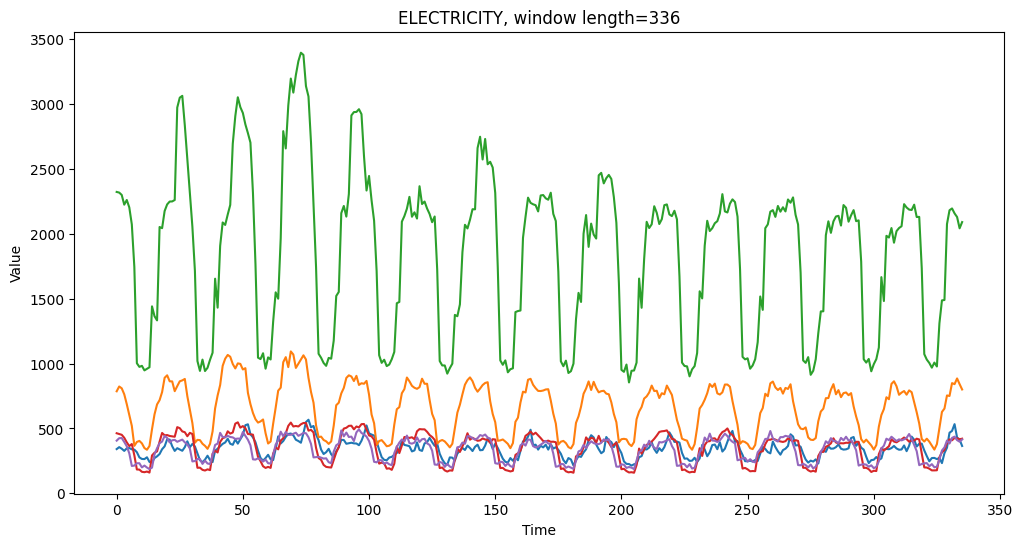

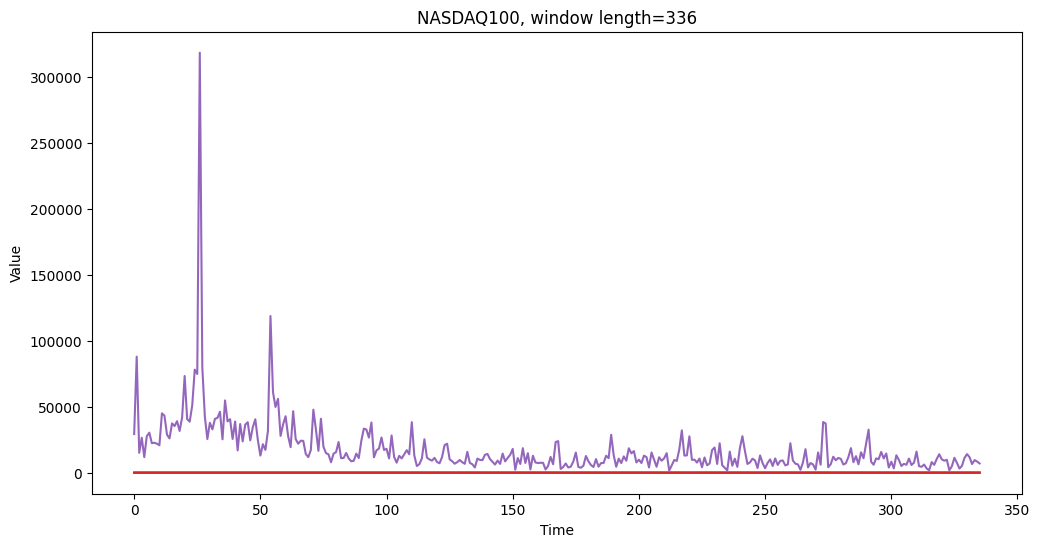

In [455]:
dataset_list = ['JONAS_NYC_taxi', 'JONAS_NYC_bike','PEMS03', 'PEMS07', 'ETT_hour', 'weather', 'electricity', 'nasdaq100']
for dataset in dataset_list:
    plt_series = PlotSeries(dataset)
    if dataset == 'PEMS03' or dataset == 'PEMS07':
        plt_series.plot(win = 1032, plot_num=5, normalize=False)
    else:
        plt_series.plot(win = 336, plot_num=5, normalize=False)